In [1]:
###############################################################################
## Figure 3 — Differential methylation (DSS), CLEAN single-pass rebuild
## Runs top-to-bottom in a fresh session. FDR = 0.05 throughout.
## Addresses reviewer comments:
##   - FDR 0.05 consistent everywhere (R2 #6)
##   - Sample labels MC09/MC24/... (R2 #7, R3)
##   - Heatmap columns ordered by age class (R3)
##   - Panel D as PROPORTIONS within trend class (R2 #9)
##   - Raw-beta (0-1) supplementary heatmap (R2 #8)
##   - Distinct color palettes per concept (R2 #5)
##   - Prints exact 5' regulatory % so the "depleted" wording can be checked (R2 #6)
##
## TWO SPOTS TO CONFIRM AGAINST YOUR ORIGINAL (they drive the reported counts):
##   [A] BLOCK 7  region-annotation PRIORITY (promoter-vs-gene-body overlap)
##   [B] BLOCK 8  TREND RULE (Increasing/Decreasing/Flat)
###############################################################################

In [2]:
###############################################################################
## BLOCK 0. Paths + parameters (single source of truth)
###############################################################################
data_dir     <- "data"
out_dir      <- "outputs"
out_data_dir <- file.path(out_dir, "data")
out_fig_dir  <- file.path(out_dir, "figures")
dir.create(out_data_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(out_fig_dir,  recursive = TRUE, showWarnings = FALSE)

bsseq_file      <- file.path(data_dir, "bsseq_snp_masked.RData")    # BSseq_obj_masked (MC11 already excluded)
gff_path        <- file.path(data_dir, "GCF_021869535.1_genomic.gff")
covariates_file <- file.path(data_dir, "combined_covariates.csv")   # columns: sample, group
stopifnot(file.exists(bsseq_file), file.exists(gff_path), file.exists(covariates_file))

FDR_CUTOFF     <- 0.05     # DML significance threshold (MATCHES MANUSCRIPT / FIGURES)
PROMOTER_UP    <- 2000     # 5' regulatory window (bp upstream)
METH_THRESHOLD <- 0.5      # mean beta to call a CpG "methylated" (Panel A)
TREND_DELTA    <- 0.10     # min |Old - Young| mean-beta change for a directional trend (BLOCK 8)
MAX_HM         <- 6000L    # heatmap row cap (display only; stratified by trend)
RECOMPUTE_DSS  <- FALSE     # TRUE to refit from scratch
set.seed(1)
sfx <- sprintf("fdr%02d", as.integer(100 * FDR_CUTOFF))

In [3]:
###############################################################################
## BLOCK 1. Libraries + helpers
###############################################################################
suppressMessages({
  library(bsseq); library(DSS)
  library(GenomicRanges); library(GenomicFeatures); library(txdbmaker)
  library(IRanges); library(GenomeInfoDb); library(rtracklayer)
  library(tidyverse)
  library(pheatmap); library(patchwork); library(scales); library(ggplotify)
  library(gridExtra)
})

# Internal library IDs ("M44-9-1yr") -> manuscript labels ("MC09")
mc_labels <- function(x) {
  mid <- stringr::str_match(x, "-(\\d+)-")[, 2]
  ifelse(is.na(mid), x, paste0("MC", sprintf("%02d", as.integer(mid))))
}
stars <- function(q) dplyr::case_when(q < 1e-3 ~ "***", q < 1e-2 ~ "**", q < 5e-2 ~ "*", TRUE ~ "")

REGION_LEVELS <- c("Gene Body", "5' Regulatory Region", "Intergenic")
# Colorblind-safe palettes (Okabe-Ito based); no red/green pairing, one family per concept
COL_AGE    <- c("Young"="#9ECAE1", "Intermediate"="#4292C6", "Old"="#08519C")                 # sequential blue (young->old)
COL_TREND  <- c("Increasing"="#D55E00", "Decreasing"="#009E73", "Flat/Irregular"="#999999")    # vermillion / bluish-green / grey
COL_SOURCE <- c("All CpGs"="#BBBBBB", "Methylated CpGs"="#E69F00", "DMLs"="#0072B2")           # grey / orange / blue
COL_REGION <- c("Gene Body"="#CC79A7", "5' Regulatory Region"="#E69F00", "Intergenic"="#56B4E9")  # purple / orange / sky-blue

In [4]:
###############################################################################
## BLOCK 2. Load BSseq
###############################################################################
load(bsseq_file)                 # -> BSseq_obj_masked
BSobj <- BSseq_obj_masked
stopifnot(inherits(BSobj, "BSseq"))
message(sprintf("BSseq: %d loci x %d samples: %s",
                nrow(BSobj), ncol(BSobj), paste(sampleNames(BSobj), collapse=", ")))

BSseq: 27102785 loci x 6 samples: M44-9-1yr, M46-14-4yr, M47-15-6yr, M48-18-8yr, M49-19-8yr, M50-24-1yr



In [5]:
###############################################################################
## BLOCK 3. Design (age classes)
###############################################################################
covariates <- readr::read_csv(covariates_file, show_col_types = FALSE)
stopifnot(all(c("sample","group") %in% names(covariates)))   # adjust names if your CSV differs

covariates <- covariates %>%
  filter(sample %in% sampleNames(BSobj)) %>%
  arrange(factor(sample, levels = sampleNames(BSobj)))

design <- tibble::column_to_rownames(covariates, "sample")
design$group <- factor(design$group, levels = c("Young","Intermediate","Old"))
stopifnot(!anyNA(design$group))
message("Groups: ", paste(rownames(design), design$group, sep="=", collapse=", "))

Groups: M44-9-1yr=Young, M46-14-4yr=Intermediate, M47-15-6yr=Intermediate, M48-18-8yr=Old, M49-19-8yr=Old, M50-24-1yr=Young



In [6]:
###############################################################################
## BLOCK 4. DSS multi-factor fit + tests (cached)
###############################################################################
fit_rds <- file.path(out_data_dir, "dml_fit.rds")
ti_rds  <- file.path(out_data_dir, "dml_test_intermediate.rds")
to_rds  <- file.path(out_data_dir, "dml_test_old.rds")

if (!RECOMPUTE_DSS && all(file.exists(c(fit_rds, ti_rds, to_rds)))) {
  dml_fit  <- readRDS(fit_rds); test_int <- readRDS(ti_rds); test_old <- readRDS(to_rds)
  message("Loaded cached DSS fit/tests.")
} else {
  dml_fit  <- DSS::DMLfit.multiFactor(BSobj, design = design, formula = ~ group)
  test_int <- DSS::DMLtest.multiFactor(dml_fit, coef = "groupIntermediate")
  test_old <- DSS::DMLtest.multiFactor(dml_fit, coef = "groupOld")
  saveRDS(dml_fit, fit_rds); saveRDS(test_int, ti_rds); saveRDS(test_old, to_rds)
  message("Fitted DSS and cached.")
}

Loaded cached DSS fit/tests.



In [7]:
###############################################################################
## BLOCK 5. Call DMLs (UNION of the two contrasts) at FDR_CUTOFF
###############################################################################
filter_dml <- function(tst) {
  as.data.frame(tst) %>% filter(!is.na(fdrs), fdrs <= FDR_CUTOFF) %>%
    transmute(chr, pos, stat, pvals, fdrs)
}
dml_int <- filter_dml(test_int)
dml_old <- filter_dml(test_old)

union_df <- bind_rows(dml_int, dml_old) %>%
  arrange(chr, pos, fdrs) %>% distinct(chr, pos, .keep_all = TRUE) %>%
  mutate(locus = paste0(chr, ":", pos))

n_union <- nrow(union_df)
message(sprintf("DMLs FDR<=%.2f  Int=%d  Old=%d  UNION=%d",
                FDR_CUTOFF, nrow(dml_int), nrow(dml_old), n_union))
write_csv(union_df, file.path(out_data_dir, paste0("DMLs_union_", sfx, ".csv")))

DMLs FDR<=0.05  Int=29789  Old=13057  UNION=39144



In [8]:
###############################################################################
## BLOCK 6. Methylation matrix for UNION DMLs; columns ORDERED BY AGE (R3)
###############################################################################
all_gr  <- granges(BSobj)
all_key <- paste0(as.character(seqnames(all_gr)), ":", start(all_gr))
ix <- match(union_df$locus, all_key)
stopifnot(!anyNA(ix))

orig_order     <- colnames(BSobj)
col_group_orig <- design[orig_order, "group"]

meth_raw0 <- bsseq::getMeth(BSobj[ix, ], type = "raw")     # loci x samples (orig order)
stopifnot(identical(colnames(meth_raw0), orig_order))

col_ord   <- order(col_group_orig, mc_labels(orig_order))  # Young->Int->Old, then MC label
meth_raw  <- meth_raw0[, col_ord, drop = FALSE]
col_group <- col_group_orig[col_ord]
colnames(meth_raw) <- mc_labels(orig_order[col_ord])

meth_z <- t(scale(t(meth_raw)))                            # per-locus z across samples (viz only)
colnames(meth_z) <- colnames(meth_raw)
message("Heatmap column order (age): ", paste(colnames(meth_raw), collapse=", "))

Heatmap column order (age): MC09, MC24, MC14, MC15, MC18, MC19



In [9]:
###############################################################################
## BLOCK 7. Annotate to genomic regions (UNION + background) + methylated CpGs
###############################################################################
# A TxDb wraps a live SQLite connection that does NOT survive saveRDS/readRDS
# (a deserialized TxDb throws "bad_weak_ptr" on first query). Cache with
# AnnotationDbi::saveDb/loadDb, which serializes the actual database.
txdb_sqlite <- file.path(out_data_dir, "txdb.sqlite")
if (file.exists(txdb_sqlite)) {
  txdb <- AnnotationDbi::loadDb(txdb_sqlite)
} else {
  txdb <- txdbmaker::makeTxDbFromGFF(gff_path, format = "gff3")
  AnnotationDbi::saveDb(txdb, txdb_sqlite)
}
genes_gr <- suppressWarnings(GenomicFeatures::genes(txdb))
prom_gr  <- promoters(genes_gr, upstream = PROMOTER_UP, downstream = 0)
gb_gr    <- GenomicRanges::reduce(c(exons(txdb),
              unlist(intronsByTranscript(txdb), use.names = FALSE)))

# harmonize seqlevels so overlaps don't error on scaffold-name mismatches
sl <- intersect(seqlevels(all_gr), seqlevels(genes_gr))
prom_gr <- keepSeqlevels(prom_gr, sl, pruning.mode = "coarse")
gb_gr   <- keepSeqlevels(gb_gr,   sl, pruning.mode = "coarse")

## [A] REGION PRIORITY = MANUSCRIPT VERSION: a CpG overlapping BOTH a gene body
##     and a 5' regulatory window is counted as 5' Regulatory (promoter wins).
##     Reproduces the paper's Gene Body = 68.3%, 5' Reg = 5.7%.
##     (To make gene body win instead, move the gene-body line to be LAST.)
annotate_region <- function(gr) {
  reg <- rep("Intergenic", length(gr))
  reg[overlapsAny(gr, gb_gr,   ignore.strand = TRUE)] <- "Gene Body"
  reg[overlapsAny(gr, prom_gr, ignore.strand = TRUE)] <- "5' Regulatory Region"  # promoter wins
  factor(reg, levels = REGION_LEVELS)
}

dml_gr <- GRanges(union_df$chr, IRanges(union_df$pos, width = 1))
union_df$region <- annotate_region(dml_gr)

bg_region <- annotate_region(all_gr)
meth_mean_all <- rowMeans(bsseq::getMeth(BSobj, type = "raw"), na.rm = TRUE)
meth_region   <- bg_region[meth_mean_all >= METH_THRESHOLD]

counts_all  <- table(bg_region)[REGION_LEVELS]
counts_meth <- table(meth_region)[REGION_LEVELS]
counts_dml  <- table(union_df$region)[REGION_LEVELS]

In [10]:
###############################################################################
## BLOCK 8. TREND CLASSIFICATION  (Increasing / Decreasing / Flat)
##   [B] RULE: monotonic across age-class means AND a minimum net change
##       (|Old - Young| >= TREND_DELTA). The magnitude gate keeps tiny,
##       noise-level shifts out of the directional classes (conservative;
##       addresses reviewer concern about inflated DML calls). Tune TREND_DELTA
##       in BLOCK 0 to loosen/tighten the Increasing/Decreasing sets.
###############################################################################
grp_lv <- c("Young","Intermediate","Old")
grp_means <- sapply(grp_lv, function(g)
  rowMeans(meth_raw[, col_group == g, drop = FALSE], na.rm = TRUE))   # loci x 3
y <- grp_means[,"Young"]; i <- grp_means[,"Intermediate"]; o <- grp_means[,"Old"]

union_df$trend <- dplyr::case_when(
  y < i & i < o & (o - y) >= TREND_DELTA ~ "Increasing",   # strictly monotonic up + >= TREND_DELTA net change
  y > i & i > o & (y - o) >= TREND_DELTA ~ "Decreasing",   # strictly monotonic down
  TRUE                                   ~ "Flat/Irregular"
)
union_df$trend <- factor(union_df$trend, levels = names(COL_TREND))
trend_counts <- table(union_df$trend)
message("Trend counts (TREND_DELTA=", TREND_DELTA, "): ",
        paste(names(trend_counts), trend_counts, sep="=", collapse=", "))

Trend counts (TREND_DELTA=0.1): Increasing=3238, Decreasing=4477, Flat/Irregular=31429



In [11]:
###############################################################################
## BLOCK 9. Panel A — genomic composition + enrichment
###############################################################################
regionA <- bind_rows(
  tibble(region=REGION_LEVELS, source="All CpGs",        count=as.integer(counts_all)),
  tibble(region=REGION_LEVELS, source="Methylated CpGs", count=as.integer(counts_meth)),
  tibble(region=REGION_LEVELS, source="DMLs",            count=as.integer(counts_dml))
) %>% group_by(source) %>% mutate(prop = count/sum(count)) %>% ungroup() %>%
  mutate(region = factor(region, REGION_LEVELS),
         source = factor(source, names(COL_SOURCE)))

enrich <- function(sig_counts) {
  purrr::map_dfr(REGION_LEVELS, function(r){
    sin <- sig_counts[[r]]; sout <- sum(sig_counts)-sin
    ain <- counts_all[[r]]; aout <- sum(counts_all)-ain
    ft <- fisher.test(matrix(c(sin,sout,ain,aout), 2))
    tibble(region=r, OR=unname(ft$estimate), p=ft$p.value)
  }) %>% mutate(q = p.adjust(p, "BH"))
}
enr_dml  <- enrich(counts_dml)
enr_meth <- enrich(counts_meth)
print(enr_dml); print(enr_meth)      # OR/q for the inset table

pA <- ggplot(regionA, aes(region, prop, fill = source)) +
  geom_col(position = position_dodge2(width = 0.72, padding = 0, preserve = "single"),
           width = 0.72, color = "black", linewidth = 0.25) +
  geom_text(aes(label = sprintf("%.1f%%", 100*prop)),
            position = position_dodge2(width = 0.72, preserve = "single"),
            vjust = -0.4, size = 2.3) +
  scale_fill_manual(values = COL_SOURCE, name = NULL) +
  scale_y_continuous(labels = percent_format(accuracy = 1),
                     breaks = c(0, 0.25, 0.5, 0.75, 1.0),
                     expand = expansion(mult = c(0, 0.28))) +
  labs(x = NULL, y = "Proportion of CpGs") +
  theme_classic(base_size = 12) +
  theme(legend.position = c(0.99, 0.99), legend.justification = c(1, 1),
        legend.background = element_rect(fill = "white", color = NA))

# significance BRACKETS: Methylated-vs-All and DML-vs-All within each region
d <- 0.72 / 3                                   # bar-center offset for the 3 dodged bars
bdf <- purrr::map_dfr(seq_along(REGION_LEVELS), function(ri) {
  r  <- REGION_LEVELS[ri]
  base <- max(regionA$prop[regionA$region == r]) + 0.04
  tibble(x1  = c(ri - d, ri - d),                       # All CpGs bar (left)
         x2  = c(ri,      ri + d),                       # Methylated ; DMLs
         y   = c(base, base + 0.09),
         lab = c(stars(enr_meth$q[enr_meth$region == r]),
                 stars(enr_dml$q[enr_dml$region  == r])))
}) %>% filter(lab != "")

tickh <- 0.015
pA <- pA +
  geom_segment(data = bdf, aes(x = x1, xend = x2, y = y, yend = y),
               inherit.aes = FALSE, linewidth = 0.4) +
  geom_segment(data = bdf, aes(x = x1, xend = x1, y = y, yend = y - tickh),
               inherit.aes = FALSE, linewidth = 0.4) +
  geom_segment(data = bdf, aes(x = x2, xend = x2, y = y, yend = y - tickh),
               inherit.aes = FALSE, linewidth = 0.4) +
  geom_text(data = bdf, aes(x = (x1 + x2) / 2, y = y, label = lab),
            inherit.aes = FALSE, vjust = -0.1, size = 3.8, fontface = "bold")

# OR/q reported in the figure legend (printed here for reference, not overlaid)
message("Panel A enrichment vs All CpGs:")
print(dplyr::transmute(enr_dml,  region, OR = round(OR, 2), q, comparison = "DML vs All"))
print(dplyr::transmute(enr_meth, region, OR = round(OR, 2), q, comparison = "Meth vs All"))

# A tibble: 3 × 4
  region                  OR            p            q
  <chr>                <dbl>        <dbl>        <dbl>
1 Gene Body            2.94  0            0           
2 5' Regulatory Region 0.873 0.0000000299 0.0000000299
3 Intergenic           0.334 0            0           
# A tibble: 3 × 4
  region                  OR     p     q
  <chr>                <dbl> <dbl> <dbl>
1 Gene Body            5.05      0     0
2 5' Regulatory Region 0.770     0     0
3 Intergenic           0.187     0     0


Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2 3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”
Panel A enrichment vs All CpGs:



# A tibble: 3 × 4
  region                  OR            q comparison
  <chr>                <dbl>        <dbl> <chr>     
1 Gene Body             2.94 0            DML vs All
2 5' Regulatory Region  0.87 0.0000000299 DML vs All
3 Intergenic            0.33 0            DML vs All
# A tibble: 3 × 4
  region                  OR     q comparison 
  <chr>                <dbl> <dbl> <chr>      
1 Gene Body             5.05     0 Meth vs All
2 5' Regulatory Region  0.77     0 Meth vs All
3 Intergenic            0.19     0 Meth vs All


In [12]:
###############################################################################
## BLOCK 10. Panel B (z-scored heatmap) + Supplement (raw beta) — age-ordered cols
###############################################################################
row_ord   <- order(union_df$trend)
ord_z     <- meth_z[row_ord, , drop=FALSE]
ord_raw   <- meth_raw[row_ord, , drop=FALSE]
ord_trend <- union_df$trend[row_ord]

sel <- if (nrow(ord_z) > MAX_HM) sort(sample(nrow(ord_z), MAX_HM)) else seq_len(nrow(ord_z))
if (length(sel) < nrow(ord_z))
  message(sprintf("Heatmap subsampled to %d of %d loci (display only).", length(sel), nrow(ord_z)))

rn <- sprintf("l%06d", seq_along(sel))
row_anno <- data.frame(Trend = ord_trend[sel]); rownames(row_anno) <- rn
matz <- ord_z[sel,,drop=FALSE];  rownames(matz) <- rn
matr <- ord_raw[sel,,drop=FALSE]; rownames(matr) <- rn
col_anno <- data.frame(Age = col_group); rownames(col_anno) <- colnames(matz)
ann_cols <- list(Trend = COL_TREND, Age = COL_AGE)

pB <- pheatmap::pheatmap(
  matz, color = colorRampPalette(c("#2c7bb6","white","#d7191c"))(255),
  cluster_rows = FALSE, cluster_cols = FALSE,          # columns already age-ordered
  annotation_row = row_anno, annotation_col = col_anno, annotation_colors = ann_cols,
  show_rownames = FALSE, fontsize_col = 10, silent = TRUE,
  main = "")

ggsave(file.path(out_fig_dir, paste0("Fig3B_heatmap_z_", sfx, ".pdf")),
       as.ggplot(pB), width = 5, height = 6, device = grDevices::cairo_pdf, bg = "white")

pS <- pheatmap::pheatmap(
  matr, color = colorRampPalette(c("white","black"))(255), breaks = seq(0,1,length.out=256),
  cluster_rows = FALSE, cluster_cols = FALSE,
  annotation_row = row_anno, annotation_col = col_anno, annotation_colors = ann_cols,
  show_rownames = FALSE, fontsize_col = 10, silent = TRUE,
  main = "Raw mCG/CG (0-1)")

ggsave(file.path(out_fig_dir, paste0("FigS2_rawbeta_heatmap_", sfx, ".pdf")),
       as.ggplot(pS), width = 6.5, height = 6, device = grDevices::cairo_pdf, bg = "white")

Heatmap subsampled to 6000 of 39144 loci (display only).



In [13]:
###############################################################################
## BLOCK 11. Panel C — age trajectories by trend (z-scored across the 3 classes)
###############################################################################
zc <- t(scale(t(grp_means)))          # z across Young/Int/Old per locus
traj <- as.data.frame(zc) %>% setNames(grp_lv) %>%
  mutate(trend = union_df$trend, locus = union_df$locus) %>%
  pivot_longer(all_of(grp_lv), names_to = "age", values_to = "z") %>%
  mutate(age = factor(age, grp_lv))

traj_mean <- traj %>% group_by(trend, age) %>%
  summarise(z = mean(z, na.rm = TRUE), .groups = "drop")

traj_bg <- traj %>% group_by(trend) %>%
  filter(locus %in% sample(unique(locus), min(400, length(unique(locus))))) %>% ungroup()

lab_n <- setNames(sprintf("%s\n(n = %d)", names(trend_counts), as.integer(trend_counts)),
                  names(trend_counts))

pC <- ggplot() +
  geom_line(data = traj_bg,  aes(age, z, group = locus), color = "grey70",
            linewidth = 0.2, alpha = 0.5) +
  geom_line(data = traj_mean, aes(age, z, color = trend, group = trend), linewidth = 1.3) +
  facet_wrap(~ trend, labeller = as_labeller(lab_n)) +
  scale_color_manual(values = COL_TREND, guide = "none") +
  scale_x_discrete(labels = c("Young"="Y", "Intermediate"="I", "Old"="O")) +
  labs(x = "Age class (Y = Young, I = Intermediate, O = Old)",
       y = "Methylation (z-scored)") +
  theme_classic(base_size = 12) +
  theme(strip.text = element_text(size = 9))

In [14]:
###############################################################################
## BLOCK 12. Panel D — genomic composition WITHIN each trend class (PROPORTIONS)
###############################################################################
panelD <- union_df %>%
  filter(trend %in% c("Increasing","Decreasing")) %>%
  count(trend, region) %>% group_by(trend) %>%
  mutate(prop = n/sum(n)) %>% ungroup() %>%
  mutate(trend = factor(trend, c("Increasing","Decreasing")),
         region = factor(region, REGION_LEVELS))

pD <- ggplot(panelD, aes(trend, prop, fill = region)) +
  geom_col(width = 0.6, color = "black", linewidth = 0.25) +
  scale_fill_manual(values = COL_REGION, name = "Genomic region") +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = expansion(mult = c(0, 0.02))) +
  labs(x = NULL, y = "Proportion of DMLs") +
  theme_classic(base_size = 12) +
  theme(legend.position = "top", legend.justification = "left",
        legend.title = element_text(size = 10), legend.text = element_text(size = 9),
        legend.key.size = unit(3.5, "mm"), legend.margin = margin(0, 0, 2, 0)) +
  guides(fill = guide_legend(title.position = "top", nrow = 2))

In [15]:
###############################################################################
## BLOCK 13. Reviewer checks + save the numbers the manuscript should cite
###############################################################################
p5_all <- regionA %>% filter(source=="All CpGs", region=="5' Regulatory Region") %>% pull(prop)
p5_dml <- regionA %>% filter(source=="DMLs",      region=="5' Regulatory Region") %>% pull(prop)
message(sprintf("5' Regulatory: All=%.2f%%  DMLs=%.2f%%  (OR=%.2f, q=%.3g)  <- check 'depleted' wording",
                100*p5_all, 100*p5_dml,
                enr_dml$OR[enr_dml$region=="5' Regulatory Region"],
                enr_dml$q[enr_dml$region=="5' Regulatory Region"]))

write_csv(
  tibble(metric = c("union_DMLs","increasing","decreasing","flat_irregular"),
         value  = c(n_union, as.integer(trend_counts[["Increasing"]]),
                    as.integer(trend_counts[["Decreasing"]]),
                    as.integer(trend_counts[["Flat/Irregular"]]))),
  file.path(out_data_dir, paste0("Fig3_key_numbers_", sfx, ".csv")))

5' Regulatory: All=4.92%  DMLs=4.33%  (OR=0.87, q=2.99e-08)  <- check 'depleted' wording



Done. Wrote Fig3_fdr05.pdf and panel/supplement PDFs to outputs/figures



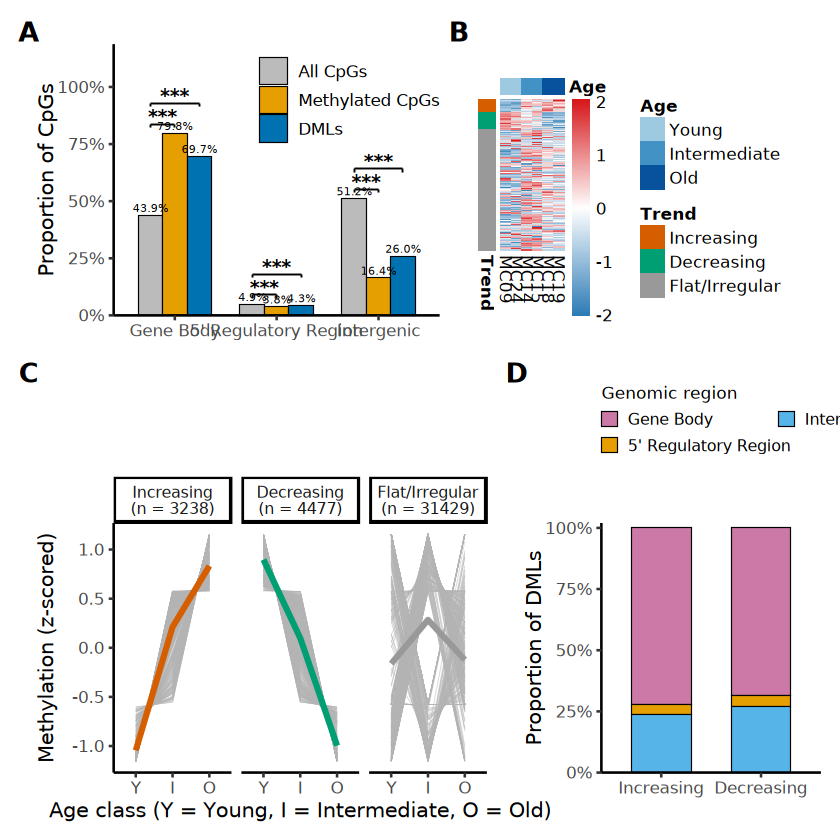

In [16]:
###############################################################################
## BLOCK 14. Assemble Figure 3 (A, B, C, D)
###############################################################################
top <- (pA | as.ggplot(pB)) + plot_layout(widths = c(1, 1.08))
bot <- (pC | pD) + plot_layout(widths = c(1.7, 1))
fig4 <- (top / bot) + plot_layout(heights = c(1, 0.92)) +
  plot_annotation(tag_levels = "A") &
  theme(plot.tag = element_text(face = "bold", size = 16))

ggsave(file.path(out_fig_dir, paste0("Fig3_", sfx, ".pdf")),
       fig4, width = 12.5, height = 8.5, device = grDevices::cairo_pdf, bg = "white")

fig4  # display assembled figure inline

writeLines(capture.output(sessionInfo()), file.path(out_dir, "sessionInfo_Fig3.txt"))
message("Done. Wrote Fig3_", sfx, ".pdf and panel/supplement PDFs to ", out_fig_dir)

In [17]:
######################################################################
## Reproducibility
######################################################################

cat("Date:", as.character(Sys.Date()), "\n")
cat("R version:", R.version.string, "\n\n")

pkgs <- c("bsseq","DSS","GenomicRanges","GenomicFeatures","txdbmaker",
          "rtracklayer","tidyverse","pheatmap","patchwork","ggplotify","gridExtra")
cat("Key package versions:\n")
for (p in pkgs) {
  if (requireNamespace(p, quietly = TRUE)) {
    cat(sprintf("  %-16s %s\n", paste0(p, ":"), as.character(packageVersion(p))))
  } else {
    cat(sprintf("  %-16s %s\n", paste0(p, ":"), "not installed"))
  }
}


Date: 2026-07-30 
R version: R version 4.4.1 (2024-06-14) 

Key package versions:
  bsseq:           1.40.0
  DSS:             2.52.0
  GenomicRanges:   1.56.2
  GenomicFeatures: 1.56.0
  txdbmaker:       1.0.1
  rtracklayer:     1.64.0
  tidyverse:       2.0.0
  pheatmap:        1.0.12
  patchwork:       1.3.0
  ggplotify:       0.1.2
  gridExtra:       2.3
